# Week 1: From Process Prediction to Decisions
# 1주차: 공정 예측에서 의사결정으로

Course design and notes: Sunwoo Kim.
강의 설계·노트: Sunwoo Kim.

Install NumPy and Matplotlib using requirements.txt, then run the cells from top to bottom. Results are written to a `week01-results` folder.
requirements.txt로 NumPy·Matplotlib을 설치한 뒤 위에서 아래로 실행합니다. 결과는 `week01-results` 폴더에 저장됩니다.


## 1. Imports and data contract

Declare units and the operating domain before fitting a model.
모델 학습 전에 단위와 운전 영역을 정의합니다.

In [1]:
import argparse
import csv
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

LOWER = np.array([300.0, 1.0, 0.8])  # T [K], tau [min], C_Af [mol/L]
UPPER = np.array([360.0, 10.0, 1.5])
K_REF = 0.2  # 1/min
T_REF = 330.0  # K
BETA = 6000.0  # K
TARGET = 0.8
DECISION_FEED = 1.2  # mol/L; fixed context for the optimization




## 2. Reference process model

Derive the CSTR steady-state map from the concentration balance.
농도 수지에서 CSTR 정상상태 mapping을 유도합니다.

In [2]:
def rate_constant(temperature):
    """Synthetic Arrhenius-type rate [1/min], temperature in kelvin."""
    temperature = np.asarray(temperature, dtype=float)
    if np.any(temperature <= 0):
        raise ValueError("Temperature must be positive in kelvin.")
    return K_REF * np.exp(BETA * (1.0 / T_REF - 1.0 / temperature))


def steady_state(inputs):
    """[T, tau, feed] -> [outlet C_A, conversion X]."""
    inputs = np.asarray(inputs, dtype=float)
    if inputs.ndim != 2 or inputs.shape[1] != 3:
        raise ValueError("Inputs must have shape (n, 3).")
    temperature, tau, feed = inputs.T
    if np.any(tau <= 0) or np.any(feed <= 0):
        raise ValueError("Residence time and feed concentration must be positive.")
    ca = feed / (1.0 + rate_constant(temperature) * tau)
    conversion = 1.0 - ca / feed
    return np.column_stack((ca, conversion))


def cost_index(inputs):
    """Dimensionless teaching index; not currency or heat duty."""
    return (inputs[:, 0] - 300.0) / 20.0 + inputs[:, 1] / 10.0




## 3. Baseline and data splits

Use only training data to fit the fixed quadratic baseline.
고정 quadratic baseline의 계수는 train 데이터로만 학습합니다.

In [3]:
def features(inputs):
    """A preselected quadratic basis, scaled using declared domain bounds."""
    scaled = 2.0 * (np.asarray(inputs) - LOWER) / (UPPER - LOWER) - 1.0
    a, b, c = scaled.T
    return np.column_stack((np.ones(len(scaled)), a, b, c,
                            a * a, b * b, c * c, a * b, a * c, b * c))


def generate_splits(seed):
    rng = np.random.default_rng(seed)
    splits = {}
    for name, size in (("train", 400), ("validation", 120), ("test", 160)):
        inputs = rng.uniform(LOWER, UPPER, size=(size, 3))
        splits[name] = (inputs, steady_state(inputs))
    return splits


def evaluate_predictions(inputs, truth, prediction):
    errors = prediction - truth
    residual = prediction[:, 0] + inputs[:, 2] * prediction[:, 1] - inputs[:, 2]
    return {
        "ca_rmse_mol_per_l": float(np.sqrt(np.mean(errors[:, 0] ** 2))),
        "conversion_rmse": float(np.sqrt(np.mean(errors[:, 1] ** 2))),
        "output_consistency_rmse_mol_per_l": float(np.sqrt(np.mean(residual ** 2))),
        "max_abs_output_consistency_mol_per_l": float(np.max(np.abs(residual))),
    }




## 4. Decision selection and reference revalidation

Select a decision and check it using the reference model on the same grid.
같은 grid에서 의사결정을 선택하고 기준 모델로 검증합니다.

In [4]:
def decision_grid():
    """The same finite candidate set is used for both models."""
    temperatures = np.linspace(LOWER[0], UPPER[0], 121)
    residence_times = np.linspace(LOWER[1], UPPER[1], 91)
    temperature, tau = np.meshgrid(temperatures, residence_times)
    candidates = np.column_stack((temperature.ravel(), tau.ravel(),
                                 np.full(temperature.size, DECISION_FEED)))
    return temperatures, residence_times, candidates


def select_decision(candidates, outputs):
    ca, conversion = outputs.T
    feasible = ((conversion >= TARGET) & (conversion <= 1.0)
                & (ca >= 0.0) & (ca <= candidates[:, 2]))
    if not np.any(feasible):
        raise RuntimeError("No feasible candidate on the declared grid.")
    return int(np.argmin(np.where(feasible, cost_index(candidates), np.inf)))


def compare_decisions(weights):
    temperatures, residence_times, candidates = decision_grid()
    truth = steady_state(candidates)
    prediction = features(candidates) @ weights
    selected = select_decision(candidates, prediction)
    benchmark = select_decision(candidates, truth)
    reference_x = float(truth[selected, 1])
    reference_feasible = bool(reference_x >= TARGET)
    selected_cost = float(cost_index(candidates)[selected])
    benchmark_cost = float(cost_index(candidates)[benchmark])
    return {
        "benchmark_kind": "lowest-cost feasible point on the declared finite grid",
        "candidate_count": len(candidates),
        "temperature_step_k": float(temperatures[1] - temperatures[0]),
        "residence_time_step_min": float(residence_times[1] - residence_times[0]),
        "fixed_feed_mol_per_l": DECISION_FEED,
        "target_conversion": TARGET,
        "surrogate_selected": {
            "temperature_k": float(candidates[selected, 0]),
            "residence_time_min": float(candidates[selected, 1]),
            "predicted_conversion": float(prediction[selected, 1]),
            "reference_conversion": reference_x,
            "reference_conversion_shortfall": max(0.0, TARGET - reference_x),
            "reference_feasible": reference_feasible,
            "cost_index": selected_cost,
            "feasible_cost_gap_to_reference_grid": (
                selected_cost - benchmark_cost if reference_feasible else None),
        },
        "reference_grid_benchmark": {
            "temperature_k": float(candidates[benchmark, 0]),
            "residence_time_min": float(candidates[benchmark, 1]),
            "conversion": float(truth[benchmark, 1]),
            "cost_index": benchmark_cost,
        },
    }




## 5. A dynamic input sequence and concentration trajectory

Inputs belong to intervals; concentrations belong to boundary times.
입력은 구간에, 농도는 경계 시점에 기록합니다.

In [5]:
def simulate_dynamic(step_time=10.0, dt=0.2, end_time=30.0):
    """Exact interval updates for this linear ODE at constant interval inputs.

    Inputs have N intervals. Concentrations have N+1 boundary observations.
    The feed and residence time are fixed; temperature is externally maintained.
    """
    if dt <= 0 or end_time <= 0 or not (0 <= step_time <= end_time):
        raise ValueError("Check dt, end_time, and step_time.")
    count = int(round(end_time / dt))
    if not np.isclose(count * dt, end_time):
        raise ValueError("end_time must be an integer multiple of dt.")
    if not np.isclose(round(step_time / dt) * dt, step_time):
        raise ValueError("step_time must be a boundary on the declared dt grid.")
    time = np.arange(count + 1) * dt
    temperature = np.where(time[:-1] < step_time, 330.0, 345.0)
    tau, feed = 5.0, DECISION_FEED
    ca = np.empty(count + 1)
    ca[0] = feed
    for i, maintained_temperature in enumerate(temperature):
        k = float(rate_constant(maintained_temperature))
        equilibrium = feed / (1.0 + k * tau)
        decay = np.exp(-(1.0 / tau + k) * dt)
        ca[i + 1] = equilibrium + (ca[i] - equilibrium) * decay
    return time, temperature, ca




## 6. Figures and downloadable results

Write reproducible data, metrics, and figures.
재현 가능한 데이터·metrics·그림을 저장합니다.

In [6]:
def make_figures(output_dir, weights, decision, trajectory):
    plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                         "axes.spines.right": False, "figure.dpi": 150})
    temperatures, residence_times, candidates = decision_grid()
    truth = steady_state(candidates)[:, 1].reshape(len(residence_times), len(temperatures))
    fig, ax = plt.subplots(figsize=(8.2, 4.8), layout="constrained")
    plot = ax.contourf(temperatures, residence_times, truth, levels=np.linspace(0, 1, 21), cmap="viridis")
    contour = ax.contour(temperatures, residence_times, truth, levels=[TARGET], colors="white")
    ax.clabel(contour, fmt={TARGET: "X = 0.8"})
    ax.set(xlabel="Maintained temperature [K]", ylabel="Residence time [min]",
           title="Synthetic CSTR: reference steady-state conversion")
    fig.colorbar(plot, ax=ax, label="Conversion [-]")
    fig.savefig(output_dir / "conversion-map.png")
    plt.close(fig)

    selected = decision["surrogate_selected"]
    tau_line = np.linspace(LOWER[1], UPPER[1], 300)
    line_inputs = np.column_stack((np.full(len(tau_line), selected["temperature_k"]),
                                  tau_line, np.full(len(tau_line), DECISION_FEED)))
    fig, ax = plt.subplots(figsize=(8.2, 4.3), layout="constrained")
    ax.plot(tau_line, steady_state(line_inputs)[:, 1], color="#0b6b57", label="Reference model")
    ax.plot(tau_line, (features(line_inputs) @ weights)[:, 1], color="#244a7f", label="Quadratic surrogate")
    ax.axhline(TARGET, color="#6b7280", linestyle="--", label="Conversion requirement")
    ax.axvline(selected["residence_time_min"], color="#ad452b", linestyle=":", label="Selected residence time")
    ax.set(xlabel="Residence time [min]", ylabel="Conversion [-]",
           title=f"Decision recheck at T = {selected['temperature_k']:.1f} K")
    ax.legend(loc="lower right")
    fig.savefig(output_dir / "decision-check.png")
    plt.close(fig)

    time, temperature, ca = trajectory
    fig, axes = plt.subplots(2, 1, figsize=(8.2, 5.0), sharex=True, layout="constrained")
    axes[0].step(time, np.r_[temperature, temperature[-1]], where="post", color="#244a7f")
    axes[0].set(ylabel="Maintained T [K]", title="Synthetic CSTR: temperature-plan response")
    axes[1].plot(time, ca, color="#0b6b57", label="Dynamic concentration")
    interval_ca = DECISION_FEED / (1.0 + rate_constant(temperature) * 5.0)
    axes[1].step(time, np.r_[interval_ca, interval_ca[-1]], where="post", linestyle="--",
                 color="#6b7280", label="Instantaneous steady-state map")
    axes[1].set(xlabel="Time [min]", ylabel="Outlet A [mol/L]")
    axes[1].legend()
    fig.savefig(output_dir / "dynamic-response.png")
    plt.close(fig)


def write_dataset(output_dir, splits):
    with (output_dir / "week01_dataset.csv").open("w", newline="", encoding="utf-8") as stream:
        writer = csv.writer(stream)
        writer.writerow(["split", "temperature_k", "residence_time_min", "feed_ca_mol_per_l",
                         "outlet_ca_mol_per_l", "conversion"])
        for split, (inputs, outputs) in splits.items():
            for values in np.column_stack((inputs, outputs)):
                writer.writerow([split, *values.tolist()])


def run_lab(output_dir="week01-results", seed=42):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    splits = generate_splits(seed)
    weights, _, rank, _ = np.linalg.lstsq(features(splits["train"][0]), splits["train"][1], rcond=None)
    if rank != 10:
        raise RuntimeError("Training design does not have full feature rank.")
    errors = {name: evaluate_predictions(inputs, truth, features(inputs) @ weights)
              for name, (inputs, truth) in splits.items()}
    decision = compare_decisions(weights)
    trajectory = simulate_dynamic()
    metrics = {
        "seed": seed,
        "parameters": {"k_ref_per_min": K_REF, "t_ref_k": T_REF, "beta_k": BETA},
        "input_columns": ["temperature_k", "residence_time_min", "feed_ca_mol_per_l"],
        "output_columns": ["outlet_ca_mol_per_l", "conversion"],
        "lower_bounds": LOWER.tolist(), "upper_bounds": UPPER.tolist(),
        "split_sizes": {name: len(inputs) for name, (inputs, _) in splits.items()},
        "baseline": "ordinary least squares on ten fixed quadratic features; not a neural network",
        "numpy_version": np.__version__,
        "prediction_metrics": errors,
        "decision": decision,
        "dynamic_indexing": "N piecewise-constant input intervals and N+1 output boundary times",
    }
    (output_dir / "results.json").write_text(json.dumps(metrics, indent=2, allow_nan=False) + "\n", encoding="utf-8")
    write_dataset(output_dir, splits)
    time, temperature, ca = trajectory
    with (output_dir / "dynamic_trajectory.csv").open("w", newline="", encoding="utf-8") as stream:
        writer = csv.writer(stream)
        writer.writerow(["boundary_time_min", "outlet_ca_mol_per_l", "temperature_for_next_interval_k"])
        for i, (t, concentration) in enumerate(zip(time, ca)):
            writer.writerow([float(t), float(concentration), float(temperature[i]) if i < len(temperature) else ""])
    make_figures(output_dir, weights, decision, trajectory)
    print(json.dumps({"test_metrics": errors["test"], "decision": decision}, indent=2))
    return metrics




## 7. Independent reference checks / 독립 기준 확인

Check one steady-state point and the full constant-input transient against analytic values.
정상상태 기준점과 일정 입력의 전체 동적 궤적을 해석적 값에 대조합니다.

In [7]:
np.testing.assert_allclose(steady_state([[330.0, 5.0, 1.2]]), [[0.6, 0.5]], atol=1e-12)
time, temperature, ca = simulate_dynamic(step_time=30.0)
np.testing.assert_allclose(ca, 0.6 + 0.6 * np.exp(-0.4 * time), atol=1e-12)
assert len(time) == len(temperature) + 1
print("Reference checks passed / 기준 확인 통과")


Reference checks passed / 기준 확인 통과


## 8. Run the full workflow / 전체 workflow 실행

Read reference feasibility before interpreting cost. A null feasible cost gap means the decision failed the reference constraint.
비용을 해석하기 전에 기준 feasibility를 확인합니다. Feasible cost gap이 null이면 기준 제약을 통과하지 못한 결정입니다.

In [8]:
metrics = run_lab(output_dir="week01-results", seed=42)


{
  "test_metrics": {
    "ca_rmse_mol_per_l": 0.03262293820597088,
    "conversion_rmse": 0.025608257579503652,
    "output_consistency_rmse_mol_per_l": 0.005671547252803907,
    "max_abs_output_consistency_mol_per_l": 0.022756718226720762
  },
  "decision": {
    "benchmark_kind": "lowest-cost feasible point on the declared finite grid",
    "candidate_count": 11011,
    "temperature_step_k": 0.5,
    "residence_time_step_min": 0.10000000000000009,
    "fixed_feed_mol_per_l": 1.2,
    "target_conversion": 0.8,
    "surrogate_selected": {
      "temperature_k": 347.0,
      "residence_time_min": 8.100000000000001,
      "predicted_conversion": 0.8001438811282473,
      "reference_conversion": 0.7978931298985088,
      "reference_conversion_shortfall": 0.0021068701014912428,
      "reference_feasible": false,
      "cost_index": 3.16,
      "feasible_cost_gap_to_reference_grid": null
    },
    "reference_grid_benchmark": {
      "temperature_k": 343.5,
      "residence_time_min": 9.8,

### Reference feasible region / 기준 feasible region

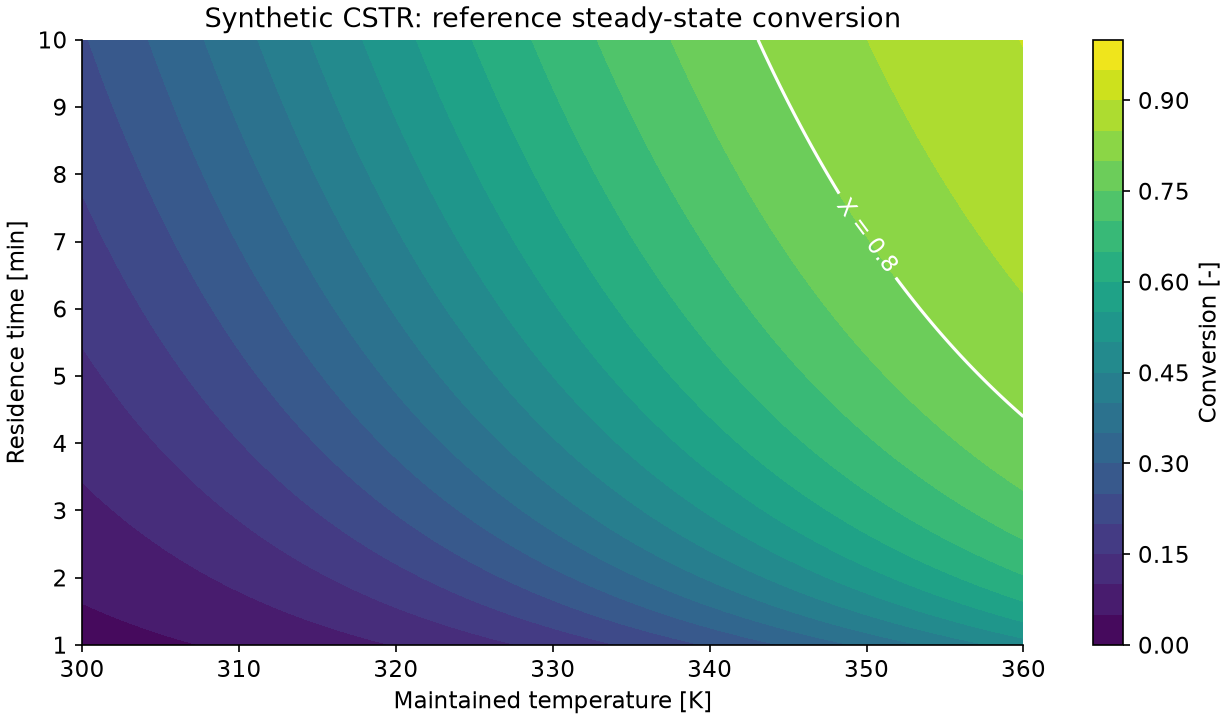

In [ ]:
figure = plt.figure(figsize=(10, 6))
plt.imshow(plt.imread(Path("week01-results") / "conversion-map.png"))
plt.axis("off")
plt.show()


### Revalidate the selected point / 선택한 운전점 재검증

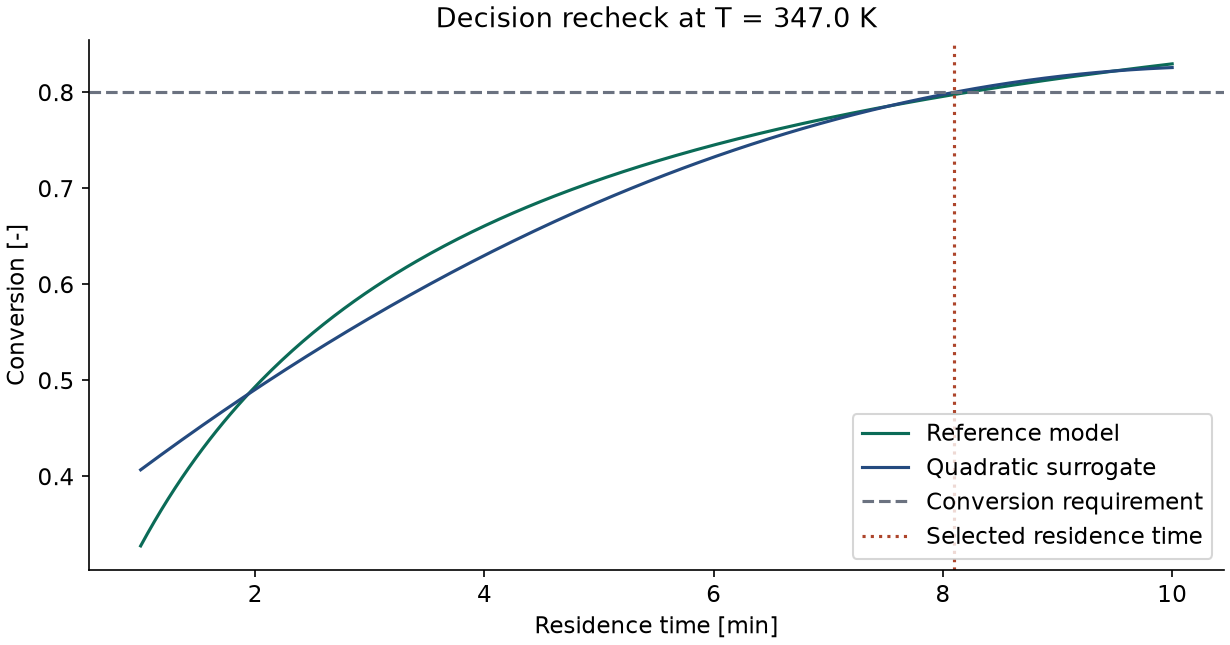

In [ ]:
figure = plt.figure(figsize=(10, 6))
plt.imshow(plt.imread(Path("week01-results") / "decision-check.png"))
plt.axis("off")
plt.show()


### Dynamic input-output indexing / 동적 입출력 indexing

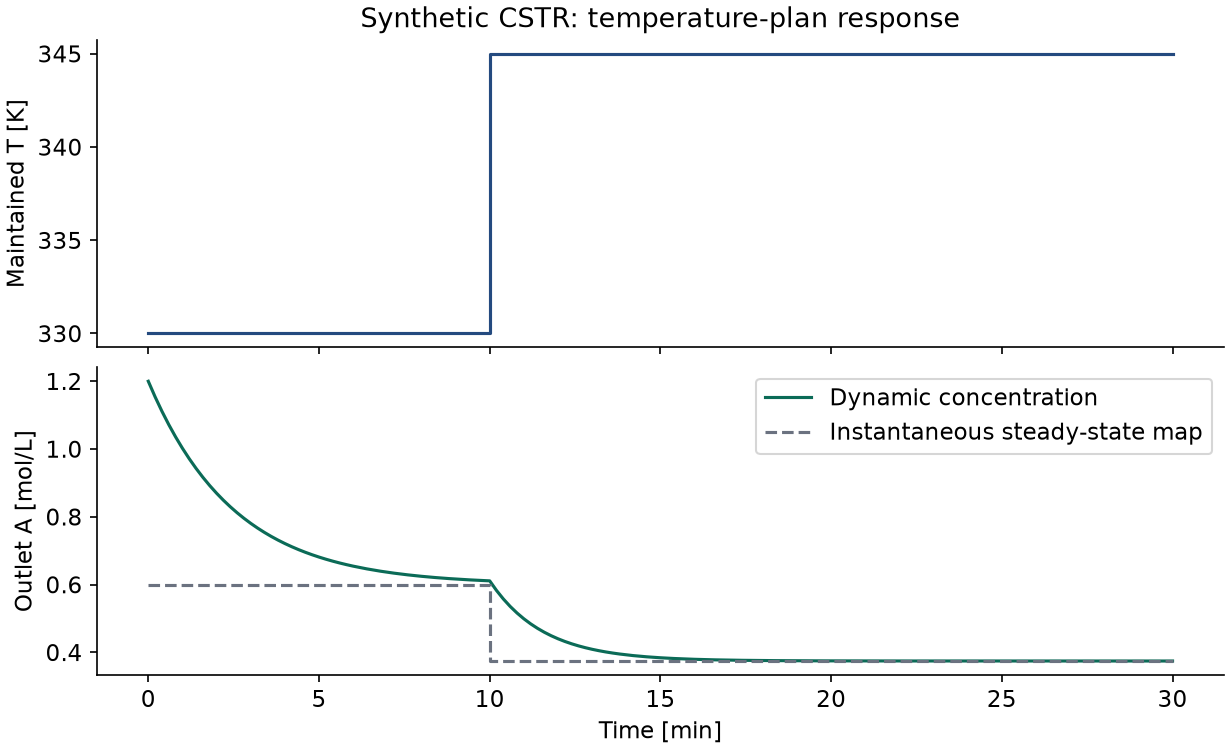

In [ ]:
figure = plt.figure(figsize=(10, 6))
plt.imshow(plt.imread(Path("week01-results") / "dynamic-response.png"))
plt.axis("off")
plt.show()


## Exercises / 연습문제

1. Derive the condition k*tau >= 4 for conversion >= 0.8. / 전환율 0.8 이상의 조건 k*tau >= 4를 유도하세요.
2. Change the seed and compare held-out RMSE and reference feasibility. / Seed를 바꾸어 test RMSE와 기준 feasibility를 비교하세요.
3. Change the temperature-step time and explain the N input intervals versus N+1 output times. / 온도 step 시점을 바꾸고 입력 구간 N개와 출력 시점 N+1개를 설명하세요.
4. Write the decision variables, fixed context, domain, units, objective, constraints, split, and revalidation rule. / 의사결정 변수·고정 context·영역·단위·목적함수·제약·분할·재검증 규칙을 작성하세요.

Course notes: https://sunboogermany.github.io/courses/surrogate-models/week-01/
Syllabus and source readings: https://sunboogermany.github.io/courses/surrogate-models/syllabus/
